
<div style="border: 3px solid #444; border-radius: 10px; padding: 20px;">

<h1 align="center"><b>PRÁCTICA 3</b></h1>

---

<h1 align="center"><b>IMPLEMENTACIÓN DE REDES NEURONALES PROFUNDAS (DNN) Y CONVOLUCIONALES (CNN)</b></h1>

---


</div>

---

| **Universitario** | Vismark Abner Choque Cachi |
|------------------|---------------------------|
| **Materia**      | DEEP LEARNING         |
| **Docente**      | Ph.D. Moises Martin Silva Choque|
| **Sigla**        | DAT-264                   |
---
---


In [ ]:
# Instalar Plotly para la visualizacion de los graficos
!pip install plotly

# Opcional: si también quieres ipywidgets para interactividad
!pip install ipywidgets

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.9 MB ? eta -:--:--
   --- ------------------------------------ 0.8/9.9 MB 3.0 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.9 MB 3.2 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.9 MB 4.0 MB/s eta 0:00:02
   -------------- ------------------------- 3.7/9.9 MB 4.1 MB/s eta 0:00:02
   ---------------- ----------------------- 4.2/9.9 MB 4.1 MB/s eta 0:00:02
   -------------------- ------------------- 5.0/9.9 MB 4.0 MB/s eta 0:00:02
   ------------------------ --------------- 6.0/9.9 MB 4.0 MB/s eta 0:00:01
   ------------------------- -------------- 6.3/9.9 MB 3.8 MB/s eta 0:00:01
   ----------------------------- ---------- 7.3/9.9 MB 3.9 MB/s eta 0:00:01
   --------------------------------- ------ 8.4/9.9 MB 4.0 MB/s eta 0:00:01
   -------------------------------------- - 9.4/9.9 MB 4.0 MB/s eta 0:00:01
   -----------------------

<h1><b>OBJETIVO</b></h1>

<div style="border: 3px solid #444; border-radius: 10px; padding: 25px; background-color: #f9f9f9;">

<h2 style="margin-top: 0;"><b>1. Preparación y manejo de datasets complejos</b></h2>
<ul style="font-size: 18px; line-height: 1.6;">
  <li>Aplicar técnicas de <b>preprocesamiento</b>, <b>normalización</b>, <b>carga eficiente</b> y <b>aumento de datos</b></li>
  <li>Trabajar específicamente con el dataset <b>CIFAR-10</b></li>
</ul>

<hr>

<h2><b>2. Implementacion y entrenamiento de modelos avanzados</b></h2>
<ul style="font-size: 18px; line-height: 1.6;">
  <li>Construir y entrenar modelos del tipo:</li>
  <ul>
    <li><b>Redes Neuronales Profundas (DNN)</b></li>
    <li><b>Redes Neuronales Convolucionales (CNN)</b></li>
  </ul>
  <li>Utilizar los frameworks:</li>
  <ul>
    <li><b>PyTorch</b></li>
    <li><b>TensorFlow / Keras</b></li>
  </ul>
</ul>

<hr>

<h2><b>3. Análisis comparativo de desempeño</b></h2>
<ul style="font-size: 18px; line-height: 1.6;">
  <li>Evaluar:</li>
  <ul>
    <li><b>Rendimiento del modelo</b> (accuracy, pérdida, sobreajuste)</li>
    <li><b>Eficiencia computacional</b> (tiempos de entrenamiento, uso de CPU/GPU)</li>
    <li><b>Facilidad de implementación</b> en cada framework</li>
  </ul>
  <li>Identificar las <b>ventajas y desventajas</b> de cada arquitectura</li>
</ul>

</div>

---


# **1) PREPARACION Y ENTORNO DE LIBRERIAS**
En esta seccion se realizara la preparación del entorno y librerías
* PyTorch: torch, torchvision, torch.utils.data, matplotlib
* TensorFlow/Keras: tensorflow, tensorflow.keras, matplotlib
* Fija semillas para reproducibilidad (torch.manual_seed y tf.random.set_seed)

## **DEFINICION DE LA SEMILLA**

In [ ]:
# Definicion de la Semilla para Reproducibilidad
SEED = 42


## **IMPORTACION DE LIBRERIAS PYTORCH**

In [ ]:

# -----------------------------------------------
# A. Librerias para PyTorch
# -----------------------------------------------
import torch
import torchvision
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim



## **IMPORTACION DE LIBRERIAS TENSORFLOW**

In [ ]:

# -----------------------------------------------
# B. Librerias para TensorFlow/Keras y Utilidades
# -----------------------------------------------
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
from collections import Counter
import time


### **VERSIONES UTILIZADAS DE LAS LIBRERIAS**

In [ ]:


# Aplicar semillas para reproducibilidad
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f"Version de PyTorch: {torch.__version__}")
print(f"Version de TensorFlow: {tf.__version__}")
print(f"Semilla definida: {SEED}")

Version de PyTorch: 2.9.0+cu126
Version de TensorFlow: 2.19.0
Semilla definida: 42


---

# **2) CARGA y PREPROCESAMIENTO DE CIFAR-10**
En esta seccion se convierten las imágenes a tensores y normalizarlas.
* PyTorch: usar transforms.Normalize() por canal.
* TensorFlow: dividir por 255 y opcionalmente usar Standardization.
* Separar conjuntos de entrenamiento y prueba, asegurando balance de clases.

## **PYTOCH carga y preprocesamiento**

Para la carga y preprocesamiento de implemento lo siguiente:
## **1. Parametros generales**
Se define el tamano del batch (cantidad de imagenes procesadas por paso) y los valores de media y desviacion estandar del dataset CIFAR-10.(estos fueron encontrados en internet)  
Estos valores se usan para normalizar las imagenes y ayudar al modelo a entrenar de forma estable

## **2. Transformaciones**
Estas operaciones preparan y mejoran los datos antes del entrenamiento

### Transformaciones de entrenamiento(aplicando la tecnica de DATA AUMENTATION)
- **RandomHorizontalFlip**: voltea las imagenes horizontalmente con probabilidad 0.5  
  Ayuda a que el modelo sea mas robusto

- **RandomCrop**: recorta la imagen de forma aleatoria manteniendo el tamano original (32x32) con un borde extra (padding 4)  
  Esto simula variaciones naturales en las imagenes

- **ToTensor**: convierte la imagen a formato tensor (PyTorch)

- **Normalize**: normaliza cada canal usando la media y desviacion estandar de CIFAR-10  
  Esto mejora la estabilidad del entrenamiento y acelera la convergencia

### Transformaciones de prueba
Solo se usan **ToTensor** y **Normalize**, ya que no se debe modificar la imagen durante la evaluacion

## **3. Carga del dataset**
Se descargan o cargan las imagenes de CIFAR-10 aplicando las transformaciones:

- `train_dataset_pt`: conjunto de entrenamiento
- `test_dataset_pt`: conjunto de prueba

## **4. DataLoaders**
Los DataLoaders organizan los datos en batches y permiten iterarlos eficientemente:

- **train_loader**: carga los datos de entrenamiento en batches y los mezcla (shuffle=True) para mejorar el aprendizaje(asi no aprende de la secuencia o orden de los datos)
- **test_loader**: carga los datos de prueba sin mezclar (shuffle=False)


In [ ]:
# ============================
# 1. Parametros generales
# ============================
BATCH_SIZE = 128

CIFAR_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR_STD  = (0.2023, 0.1994, 0.2010)

# ============================
# 2. Transformaciones
# ============================
# APLICACION DE DATA Augmentation
transform_train = torchvision.transforms.Compose([
    torchvision.transforms.RandomHorizontalFlip(p=0.5),
    torchvision.transforms.RandomCrop(32, padding=4),
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

transform_test = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize(CIFAR_MEAN, CIFAR_STD),
])

# ============================
# 3. Carga del dataset
# ============================
train_dataset_pt = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)

test_dataset_pt = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

# ============================
# 4. dataLoaders
# ============================
train_loader = DataLoader(train_dataset_pt, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader  = DataLoader(test_dataset_pt,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2) # FALSE para la reproducibilidad

print("PyTorch - Imagenes de entrenamiento:", len(train_dataset_pt))
print("PyTorch - Imagenes de prueba:", len(test_dataset_pt))


PyTorch - Imagenes de entrenamiento: 50000
PyTorch - Imagenes de prueba: 10000


### **PYTORCH Balanceo de Datos**  
En esta seccion de visualiza si los datos estan balanceados.  
El balanceo es importante porque evita que el modelo aprenda mas sobre unas clases que sobre otras  
Si una clase tiene muchas mas imagenes, la red puede volverse dependiente de esa clase y fallar al predecir las menos representadas

In [ ]:
import plotly.express as px
from collections import Counter

# 1. Contar etiquetas del dataset
train_labels = [label for _, label in train_dataset_pt]
label_counts = Counter(train_labels)

# 2. Crear DataFrame
df_plot = pd.DataFrame({
    "Clase": [train_dataset_pt.classes[i] for i in range(10)],
    "Cantidad": [label_counts[i] for i in range(10)]
})

# 3. Grafico mejorado
fig = px.bar(
    df_plot,
    x="Clase",
    y="Cantidad",
    text="Cantidad",
    title="Distribucion de Imagenes por Clase — CIFAR-10 (Entrenamiento)",
    labels={"Clase": "Categoria", "Cantidad": "Numero de Imagenes"},
)

fig.update_traces(
    textposition="outside",
    marker=dict(line=dict(width=1.5, color="black"))
)

fig.update_layout(

    title_x=0.5,
    font=dict(size=18),
    bargap=0.2,
    plot_bgcolor="white",
    xaxis=dict(showgrid=False),
    yaxis=dict(
        gridcolor="lightgray",
        range=[0, max(df_plot["Cantidad"]) * 1.25]
    ),
)

fig.show()


### **PYTORCH Ejemplos por cada categoria**

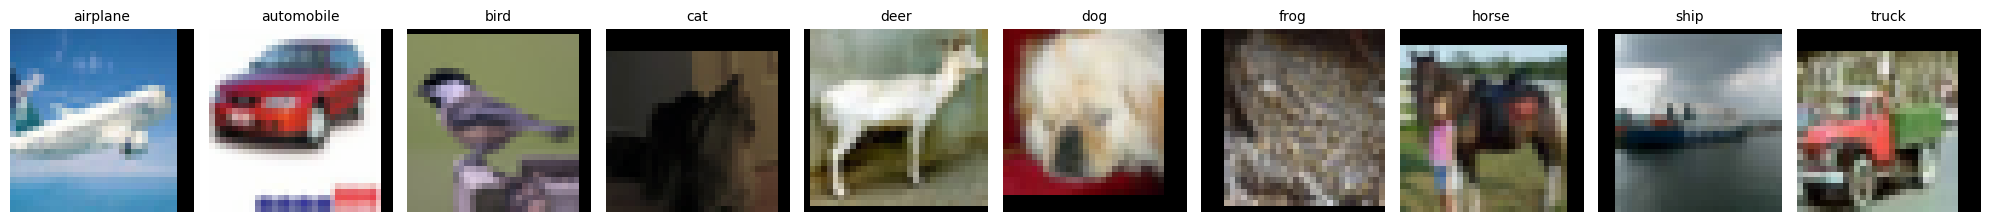

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Funcion para desnormalizar la imagen
def imshow(img):
    img = img.numpy().transpose((1, 2, 0))  # (C,H,W) -> (H,W,C)
    img = img * np.array(CIFAR_STD) + np.array(CIFAR_MEAN)  # desnormalizar
    img = np.clip(img, 0, 1)  # asegurar rango [0,1]
    return img

# Clases del dataset
classes = train_dataset_pt.classes
num_classes = len(classes)

# Crear un diccionario para guardar la primera imagen de cada clase
class_images = {}

# Iterar sobre el DataLoader hasta tener una imagen de cada clase
for images, labels in train_loader:
    for img, label in zip(images, labels):
        if label.item() not in class_images:
            class_images[label.item()] = img
        if len(class_images) == num_classes:
            break
    if len(class_images) == num_classes:
        break

# Configurar figura
fig, axes = plt.subplots(1, num_classes, figsize=(num_classes*2, 2.5))

# Mostrar las imagenes
for i, label in enumerate(range(num_classes)):
    img = imshow(class_images[label])
    axes[i].imshow(img)
    axes[i].set_title(classes[label], fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


---
---

## **TENSORFLOW carga y preprocesamiento**

In [ ]:
# ============================
# 1. Carga del dataset
# ============================
(x_train_tf, y_train_tf), (x_test_tf, y_test_tf) = tf.keras.datasets.cifar10.load_data()


# Copia de imagenes reales (sin normalizar)
x_train_raw = x_train_tf.copy()
x_test_raw  = x_test_tf.copy()

# ============================
# 2 Normalizacion de las imagenes (Dividir por 255)
# ============================
x_train_tf = x_train_tf.astype('float32') / 255.0
x_test_tf = x_test_tf.astype('float32') / 255.0

# ============================
# 3 Preparacion de etiquetas
# ============================
y_train_tf = y_train_tf.reshape(-1)
y_test_tf = y_test_tf.reshape(-1)

# ============================
# 4. NORMALIZACION CON MEDIA Y STD DE CIFAR-10
# ============================
CIFAR_MEAN_TF = np.array([0.4914, 0.4822, 0.4465])
CIFAR_STD_TF = np.array([0.2023, 0.1994, 0.2010])

x_train_tf = (x_train_tf - CIFAR_MEAN_TF) / CIFAR_STD_TF
x_test_tf = (x_test_tf - CIFAR_MEAN_TF) / CIFAR_STD_TF

# ============================
# 5. AUMENTO DE DATOS (DATA AUGMENTATION)
# ============================
def augment_data(images, labels):
    # Flip horizontal
    images = tf.image.random_flip_left_right(images)

    # Padding para imagen individual (rank 3)
    images = tf.pad(images, [[4, 4], [4, 4], [0, 0]], mode='REFLECT')

    # Recorte aleatorio de vuelta a 32x32
    images = tf.image.random_crop(images, size=[32, 32, 3])

    return images, labels

# ============================
# 6. CREACIÓN DE DATASETS CON AUMENTO DE DATOS
# ============================
BATCH_SIZE = 128

train_dataset = tf.data.Dataset.from_tensor_slices((x_train_tf, y_train_tf)) # entrenamiento imagne, etiqueta
train_dataset = train_dataset.map(augment_data, num_parallel_calls=tf.data.AUTOTUNE) # aplica data augmentation
train_dataset = train_dataset.shuffle(10000) # mezcla de imagenes
train_dataset = train_dataset.batch(BATCH_SIZE) # lotes de imagenes
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE) # carga anticipada de batch

test_dataset = tf.data.Dataset.from_tensor_slices((x_test_tf, y_test_tf)) # similar para evaluacion
test_dataset = test_dataset.batch(BATCH_SIZE) # tamaño de cada batch
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)


### **TENSORFLOW Balanceo de Datos**

In [ ]:
# Nombres de clases CIFAR-10 (mismo orden que PyTorch)
classes_tf = ['airplane','automobile','bird','cat','deer',
              'dog','frog','horse','ship','truck']

# Contar etiquetas en el set de entrenamiento
label_counts = Counter(y_train_tf)

# Crear DataFrame para Plotly
df_plot = pd.DataFrame({
    "Clase": classes_tf,
    "Cantidad": [label_counts[i] for i in range(10)]
})

# 4. Grafico de barras
fig = px.bar(
    df_plot,
    x="Clase",
    y="Cantidad",
    text="Cantidad",
    title="Distribucion de Imagenes por Clase — CIFAR-10 (Entrenamiento)",
    labels={"Clase": "Categoria", "Cantidad": "Numero de Imagenes"},
)

# ---- ESTILOS MEJORADOS ----
fig.update_traces(
    textposition="outside",
    marker=dict(color='lightcoral',line=dict(width=1.5, color="black"))
)

fig.update_layout(
    title_x=0.5,
    font=dict(size=16),
    bargap=0.2,
    plot_bgcolor="white",
    xaxis=dict(showgrid=False),
    yaxis=dict(
        gridcolor="lightgray",
        range=[0, max(df_plot["Cantidad"]) * 1.25]
    ),
)

fig.show()


### **TENSORFLOW Ejemplos por cada categoria**

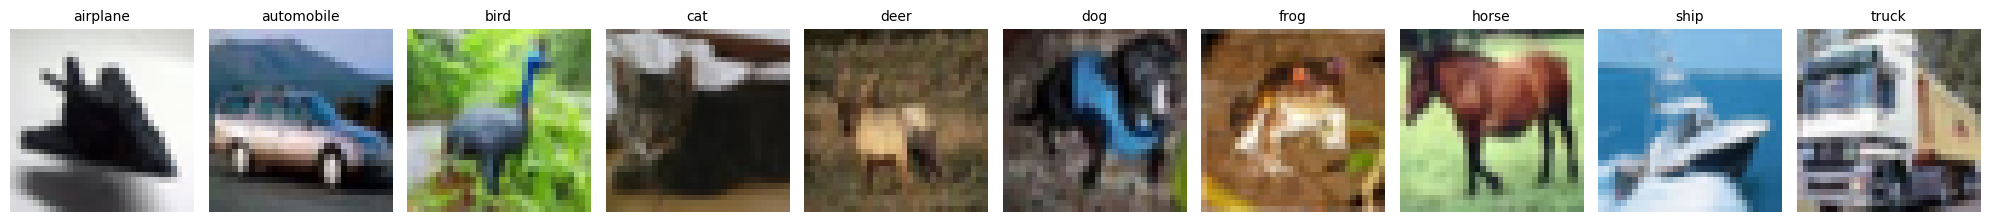

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Imagenes reales, sin procesar
images_to_show = []
labels_to_show = []

for cls in range(10):  # 10 clases CIFAR-10
    idx = np.where(y_train_tf == cls)[0][0]
    images_to_show.append(x_train_raw[idx])  # <-- AQUÍ EL CAMBIO
    labels_to_show.append(cls)

# Configurar figura
N = len(images_to_show)
fig, axes = plt.subplots(1, N, figsize=(N * 2, 2.5))

for i in range(N):
    axes[i].imshow(images_to_show[i])
    axes[i].set_title(classes[labels_to_show[i]], fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()


---

# **3) IMPLEMENTACION DE UN DNN (Multilayer Perceptron)**


### Modelo DNN: Tecnicas Implementadas

El modelo `ModeloDNN` que implementare combina varias **tecnicas de Deep Learning** que permiten entrenar de manera eficiente y mejorar la generalizacion en tareas de clasificacion de imagenes

- **Flatten**  
    - Convierte las imagenes de entrada de tamaño `(3, 32, 32)` en un vector unidimensional de 3072 elementos
    - Permite pasar la informacion a las **capas totalmente conectadas**

- **Capas Fully Connected (Lineales)**  
    - Aprenden combinaciones lineales de las caracteristicas de entrada
    - Extraen representaciones jerarquicas de la informacion

- **He/Kaiming Initialization**  
    - Inicializacion de pesos que esta especialmente diseñada para activaciones ReLU
    - Asegura que las activaciones no se saturen al inicio y que el gradiente fluya correctamente

- **Batch Normalization**   
    - Normaliza las activaciones para que tengan media cero y desviacion estandar uno
    - Estabiliza y acelera el entrenamiento, y reduce la sensibilidad a la inicializacion de pesos

- **Residual Connections**    
    - Inspiradas en ResNets, suman la entrada transformada de cada bloque a la salida de la capa lineal
    - Facilitan el flujo de gradientes y evitan el desvanecimiento del gradiente en redes profundas

- **ReLU Activation**  
    - Funcion de activacion no lineal que introduce no linealidad en la red.  
    - Evita saturaciones y permite un aprendizaje mas rapido

- **Dropout**  
    - Apaga aleatoriamente un porcentaje de neuronas (por ejemplo, 30%) durante el entrenamiento  
    - Previene sobreajuste y obliga a la red a no depender de neuronas especificas


## **PYTORCH DNN**




#### **MODELO**

In [ ]:
class ModeloDNN(nn.Module):
    def __init__(self, dropout_prob=0.3):
        super().__init__()
        self.flatten = nn.Flatten()

        # Capa 1: 3072 → 1024
        self.fc1 = nn.Linear(3072, 1024)
        self.bn1 = nn.BatchNorm1d(1024)

        # Capa 2: 1024 → 512
        self.fc2 = nn.Linear(1024, 512)
        self.bn2 = nn.BatchNorm1d(512)

        # Capa 3: 512 → 512
        self.fc3 = nn.Linear(512, 512)
        self.bn3 = nn.BatchNorm1d(512)

        # ---- Residual 1: de capa 1 → capa 3 ----
        self.res_1_3 = nn.Linear(1024, 512)

        # Capa 4: 512 → 256
        self.fc4 = nn.Linear(512, 256)
        self.bn4 = nn.BatchNorm1d(256)

        # Capa 5: 256 → 128
        self.fc5 = nn.Linear(256, 128)
        self.bn5 = nn.BatchNorm1d(128)

        # ---- Residual 2: de capa 3 → capa 5 ----
        self.res_3_5 = nn.Linear(512, 128)

        # Capa 6: 128 → 64
        self.fc6 = nn.Linear(128, 64)
        self.bn6 = nn.BatchNorm1d(64)

        # ---- Residual 3: de capa 5 → capa 6 ----
        self.res_5_6 = nn.Linear(128, 64)

        # Salida final
        self.fc_out = nn.Linear(64, 10)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(dropout_prob)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.flatten(x)

        # ----- CAPA 1 -----
        out1 = self.relu(self.bn1(self.fc1(x)))
        out1 = self.dropout(out1)

        # ----- CAPA 2 -----
        out2 = self.relu(self.bn2(self.fc2(out1)))
        out2 = self.dropout(out2)

        # ----- CAPA 3 + Residual (salto desde capa 1) -----
        out3 = self.fc3(out2)
        skip_1_3 = self.res_1_3(out1)
        out3 = self.relu(self.bn3(out3 + skip_1_3))
        out3 = self.dropout(out3)

        # ----- CAPA 4 -----
        out4 = self.relu(self.bn4(self.fc4(out3)))
        out4 = self.dropout(out4)

        # ----- CAPA 5 + Residual (salto desde capa 3) -----
        out5 = self.fc5(out4)
        skip_3_5 = self.res_3_5(out3)
        out5 = self.relu(self.bn5(out5 + skip_3_5))
        out5 = self.dropout(out5)

        # ----- CAPA 6 + Residual (salto desde capa 5) -----
        out6 = self.fc6(out5)
        skip_5_6 = self.res_5_6(out5)
        out6 = self.relu(self.bn6(out6 + skip_5_6))
        out6 = self.dropout(out6)

        # ----- SALIDA -----
        out = self.fc_out(out6)
        return out
# Definir dispositivo (se reutiliza para todos los modelos PyTorch)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo utilizado: {device}")
model_dnn_pt = ModeloDNN(dropout_prob=0.3).to(device)
print(model_dnn_pt)

Dispositivo utilizado: cuda
ModeloDNN(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc1): Linear(in_features=3072, out_features=1024, bias=True)
  (bn1): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc2): Linear(in_features=1024, out_features=512, bias=True)
  (bn2): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc3): Linear(in_features=512, out_features=512, bias=True)
  (bn3): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res_1_3): Linear(in_features=1024, out_features=512, bias=True)
  (fc4): Linear(in_features=512, out_features=256, bias=True)
  (bn4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (fc5): Linear(in_features=256, out_features=128, bias=True)
  (bn5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (res_3_5): Linear(in_features=512, out_features=128, bias=True)
  (fc6): Linear(in

### **ENTRENAMIENTO**

Epoch [1/90]  Train Loss: 1.7380, Train Acc: 0.3767  Test Loss: 1.7139, Test Acc: 0.3826
Epoch [10/90]  Train Loss: 1.3991, Train Acc: 0.4980  Test Loss: 1.3486, Test Acc: 0.5143
Epoch [20/90]  Train Loss: 1.2816, Train Acc: 0.5407  Test Loss: 1.2544, Test Acc: 0.5498
Epoch [30/90]  Train Loss: 1.2076, Train Acc: 0.5678  Test Loss: 1.1976, Test Acc: 0.5728
Epoch [40/90]  Train Loss: 1.1404, Train Acc: 0.5943  Test Loss: 1.1478, Test Acc: 0.5925
Epoch [50/90]  Train Loss: 1.0902, Train Acc: 0.6122  Test Loss: 1.1198, Test Acc: 0.6051
Epoch [60/90]  Train Loss: 1.0526, Train Acc: 0.6269  Test Loss: 1.0961, Test Acc: 0.6094
Epoch [70/90]  Train Loss: 1.0097, Train Acc: 0.6406  Test Loss: 1.0764, Test Acc: 0.6152
Epoch [80/90]  Train Loss: 0.9793, Train Acc: 0.6538  Test Loss: 1.0492, Test Acc: 0.6266
Epoch [90/90]  Train Loss: 0.9472, Train Acc: 0.6631  Test Loss: 1.0442, Test Acc: 0.6225

Tiempo de entrenamiento DNN PyTorch: 3504.87 segundos
Mejor precisión de prueba: 0.6327


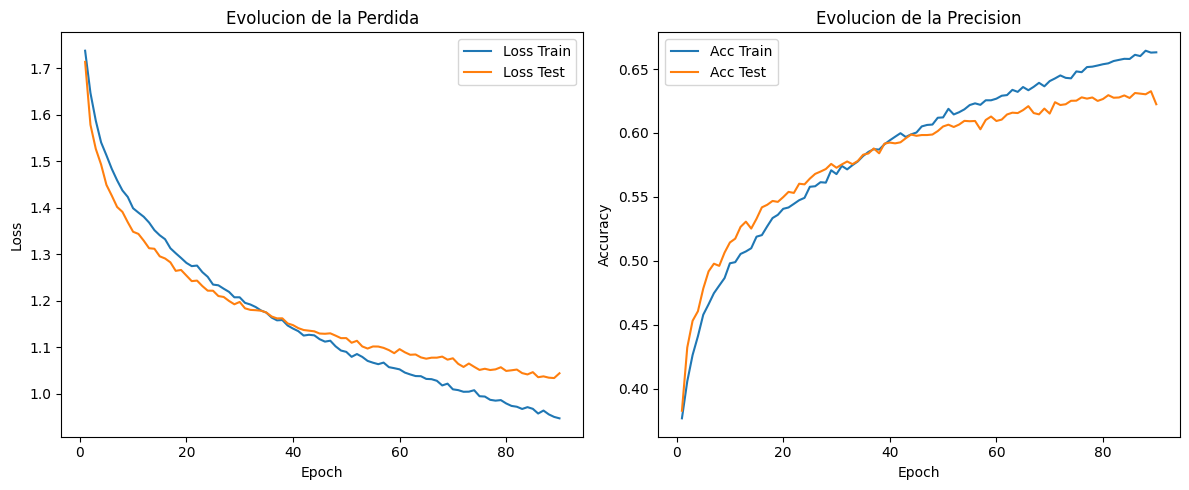

In [ ]:
# PARAMETROS DE ENTRENAMIENTO
# ============================
# 1. parametros generales
# ============================
EPOCHS = 90
LEARNING_RATE = 0.001
EARLY_STOP_PATIENCE = 5  # numero de epocas sin mejora antes de detener
EARLY_STOP_DELTA = 1e-4   # minima mejora para resetear paciencia

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dnn_pt.parameters(), lr=LEARNING_RATE)

perdidas_entrenamiento, perdidas_prueba = [], []
precision_entrenamiento, precision_prueba = [], []

mejor_perdida = float('inf')
epocas_sin_mejora = 0

start_time_dnn_pt = time.time() # apar el calculo del tiempo

for epoch in range(EPOCHS):
    # ============================
    # Entrenamiento
    # ============================
    model_dnn_pt.train()
    for imagenes, etiquetas in train_loader:
        imagenes, etiquetas = imagenes.to(device, non_blocking=True), etiquetas.to(device, non_blocking=True)

        optimizer.zero_grad()
        salidas = model_dnn_pt(imagenes)
        perdida = criterion(salidas, etiquetas)

        perdida.backward()
        optimizer.step()

    # ============================
    # Evaluacion (train + test) - Cada epoca para mejor comparacion
    # ============================
    model_dnn_pt.eval()

    # ---- Train ----
    acumulado_perdida, correctos, total = 0.0, 0, 0
    with torch.no_grad():
        for imagenes, etiquetas in train_loader:
            imagenes, etiquetas = imagenes.to(device, non_blocking=True), etiquetas.to(device, non_blocking=True)
            salidas = model_dnn_pt(imagenes)
            perdida = criterion(salidas, etiquetas)

            acumulado_perdida += perdida.item() * imagenes.size(0)
            _, prediccion = salidas.max(1)
            total += etiquetas.size(0)
            correctos += prediccion.eq(etiquetas).sum().item()

    perdida_train = acumulado_perdida / total
    precision_train = correctos / total
    perdidas_entrenamiento.append(perdida_train)
    precision_entrenamiento.append(precision_train)

    # ---- Test ----
    acumulado_perdida, correctos, total = 0.0, 0, 0
    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes, etiquetas = imagenes.to(device, non_blocking=True), etiquetas.to(device, non_blocking=True)
            salidas = model_dnn_pt(imagenes)
            perdida = criterion(salidas, etiquetas)

            acumulado_perdida += perdida.item() * imagenes.size(0)
            _, prediccion = salidas.max(1)
            total += etiquetas.size(0)
            correctos += prediccion.eq(etiquetas).sum().item()

    perdida_test = acumulado_perdida / total
    precision_test = correctos / total
    perdidas_prueba.append(perdida_test)
    precision_prueba.append(precision_test)

    # Imprimir cada 10 epocas para no saturar la salida
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}]  "
              f"Train Loss: {perdida_train:.4f}, Train Acc: {precision_train:.4f}  "
              f"Test Loss: {perdida_test:.4f}, Test Acc: {precision_test:.4f}")

    # ============================
    # Early Stopping
    # ============================
    if perdida_test + EARLY_STOP_DELTA < mejor_perdida:
        mejor_perdida = perdida_test
        epocas_sin_mejora = 0
        torch.save(model_dnn_pt.state_dict(), "best_model_dnn_pt.pt")
    else:
        epocas_sin_mejora += 1
        if epocas_sin_mejora >= EARLY_STOP_PATIENCE:
            print(f"Early stopping: no mejora en {EARLY_STOP_PATIENCE} epocas.")
            break

training_time_dnn_pt = time.time() - start_time_dnn_pt

print(f"\nTiempo de entrenamiento DNN PyTorch: {training_time_dnn_pt:.2f} segundos")
print(f"Mejor precision de prueba: {max(precision_prueba):.4f}")

# ============================
# Graficos
# ============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(range(1, len(perdidas_entrenamiento)+1), perdidas_entrenamiento, label='Loss Train')
plt.plot(range(1, len(perdidas_prueba)+1), perdidas_prueba, label='Loss Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolucion de la Perdida')
plt.legend()

plt.subplot(1,2,2)
plt.plot(range(1, len(precision_entrenamiento)+1), precision_entrenamiento, label='Acc Train')
plt.plot(range(1, len(precision_prueba)+1), precision_prueba, label='Acc Test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Evolucion de la Precision')
plt.legend()

plt.tight_layout()
plt.show()


## **TENSORFLOW DNN**


#### **MODELO**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model

def build_residual_dnn(dropout_rate=0.3):

    inp = layers.Input(shape=(32, 32, 3))
    x = layers.Flatten()(inp)

    # ---------- CAPA 1: 3072 → 1024 ----------
    x1 = layers.Dense(1024, kernel_initializer='he_normal')(x)
    x1 = layers.BatchNormalization()(x1)
    x1 = layers.ReLU()(x1)
    x1 = layers.Dropout(dropout_rate)(x1)

    # ---------- CAPA 2: 1024 → 512 --------
    x2 = layers.Dense(512, kernel_initializer='he_normal')(x1)
    x2 = layers.BatchNormalization()(x2)
    x2 = layers.ReLU()(x2)
    x2 = layers.Dropout(dropout_rate)(x2)

    # ---------- CAPA 3: 512 → 512 ---------
    # Residual desde Capa 1 → 3
    res_1_3 = layers.Dense(512, kernel_initializer='he_normal')(x1)

    x3 = layers.Dense(512, kernel_initializer='he_normal')(x2)
    x3 = layers.BatchNormalization()(x3)

    x3 = layers.Add()([x3, res_1_3])
    x3 = layers.ReLU()(x3)
    x3 = layers.Dropout(dropout_rate)(x3)

    # ---------- CAPA 4: 512 → 256 ----------
    x4 = layers.Dense(256, kernel_initializer='he_normal')(x3)
    x4 = layers.BatchNormalization()(x4)
    x4 = layers.ReLU()(x4)
    x4 = layers.Dropout(dropout_rate)(x4)

    # ---------- CAPA 5: 256 → 128 ---------
    # Residual desde Capa 3 → 5
    res_3_5 = layers.Dense(128, kernel_initializer='he_normal')(x3)

    x5 = layers.Dense(128, kernel_initializer='he_normal')(x4)
    x5 = layers.BatchNormalization()(x5)

    x5 = layers.Add()([x5, res_3_5])
    x5 = layers.ReLU()(x5)
    x5 = layers.Dropout(dropout_rate)(x5)

    # ---------- CAPA 6: 128 → 64 ----------
    # Residual desde Capa 5 → 6
    res_5_6 = layers.Dense(64, kernel_initializer='he_normal')(x5)

    x6 = layers.Dense(64, kernel_initializer='he_normal')(x5)
    x6 = layers.BatchNormalization()(x6)

    x6 = layers.Add()([x6, res_5_6])
    x6 = layers.ReLU()(x6)
    x6 = layers.Dropout(dropout_rate)(x6)

    # ---------- SALIDA ----------
    out = layers.Dense(10, activation='linear')(x6)

    return Model(inputs=inp, outputs=out)


# Construccion del modelo
model_dnn_tf = build_residual_dnn(dropout_rate=0.3)

# Compilacion
model_dnn_tf.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

model_dnn_tf.summary()


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_7 (Flatten) │ (None, 3072)      │          0 │ input_layer_7[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_68 (Dense)    │ (None, 1024)      │  3,146,752 │ flatten_7[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 1024)      │      4,096 │ dense_68[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_42 (ReLU)     │ (None, 1024)      │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_42          │ (None, 1024)      │          0 │ re_lu_42[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_69 (Dense)    │ (None, 512)       │    524,800 │ dropout_42[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_69[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_43 (ReLU)     │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_43          │ (None, 512)       │          0 │ re_lu_43[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_71 (Dense)    │ (None, 512)       │    262,656 │ dropout_43[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 512)       │      2,048 │ dense_71[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_70 (Dense)    │ (None, 512)       │    524,800 │ dropout_42[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 512)       │          0 │ batch_normalizat… │
│                     │                   │            │ dense_70[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_44 (ReLU)     │ (None, 512)       │          0 │ add_20[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_44          │ (None, 512)       │          0 │ re_lu_44[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_72 (Dense)    │ (None, 256)       │    131,328 │ dropout_44[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256)       │      1,024 │ dense_72[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_45 (ReLU)     │ (None, 256)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_45          │ (None, 256)       │          0 │ re_lu_45[0][0]    │
│ (Dropout)           │                   │            │                 

 Total params: 4,716,042 (17.99 MB)

 Trainable params: 4,711,050 (17.97 MB)

 Non-trainable params: 4,992 (19.50 KB)

### **ENTRENAMIENTO**


Epoch 1/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 25s 33ms/step - accuracy: 0.1808 - loss: 2.3782 - val_accuracy: 0.3569 - val_loss: 1.8394
Epoch 2/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.2896 - loss: 1.9447 - val_accuracy: 0.3979 - val_loss: 1.6938
Epoch 3/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.3308 - loss: 1.8455 - val_accuracy: 0.4281 - val_loss: 1.6339
Epoch 4/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - accuracy: 0.3618 - loss: 1.7760 - val_accuracy: 0.4459 - val_loss: 1.5801
Epoch 5/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.3787 - loss: 1.7289 - val_accuracy: 0.4591 - val_loss: 1.5415
Epoch 6/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.3961 - loss: 1.6843 - val_accuracy: 0.4608 - val_loss: 1.5301
Epoch 7/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step - accuracy: 0.4099 - loss: 1.6480 - val_accuracy: 0.4870 - val_loss: 1.4603
Epoch 8/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.4237 - loss: 1.6175 - val_a

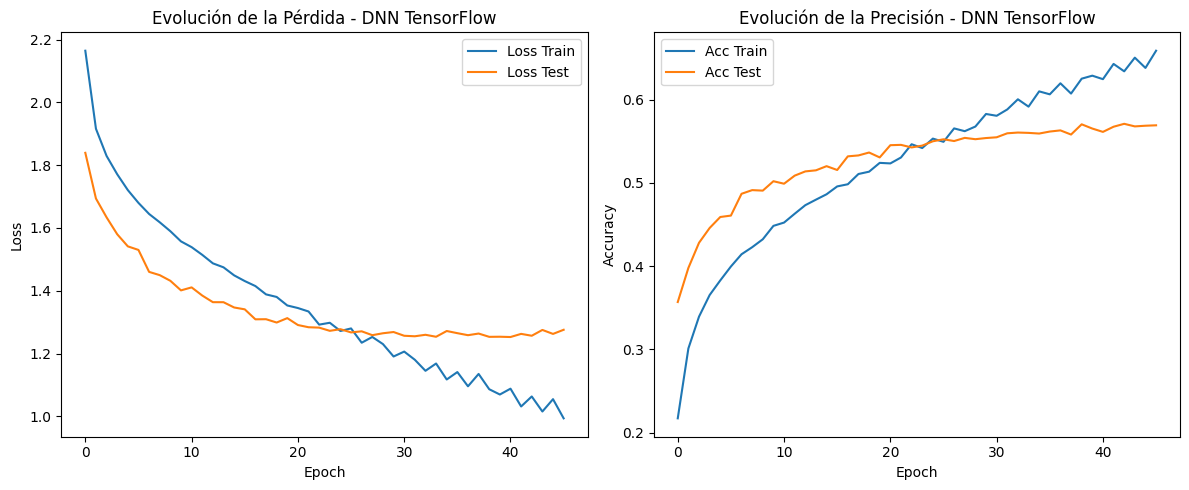

In [ ]:
# ============================
# Parametros de Entrenamiento
# ============================
EPOCHS_TF = 90
# Callbacks
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    min_delta=1e-4,
    restore_best_weights=True
)

# ============================
# Entrenamiento
# ============================
start_time_dnn_tf = time.time()

history_dnn_tf = model_dnn_tf.fit(
    train_dataset,
    epochs=EPOCHS_TF,
    validation_data=test_dataset,
    callbacks=[early_stopping],
    verbose=1
)

training_time_dnn_tf = time.time() - start_time_dnn_tf

# ============================
# Guardar metricas
# ============================
perdidas_entrenamiento_tf_dnn = history_dnn_tf.history['loss']
perdidas_prueba_tf_dnn = history_dnn_tf.history['val_loss']
precision_entrenamiento_tf_dnn = history_dnn_tf.history['accuracy']
precision_prueba_tf_dnn = history_dnn_tf.history['val_accuracy']

print(f"\nTiempo de entrenamiento DNN TensorFlow: {training_time_dnn_tf:.2f} segundos")
print(f"Mejor precision de prueba: {max(precision_prueba_tf_dnn):.4f}")

# ============================
# Graficos
# ============================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(perdidas_entrenamiento_tf_dnn, label='Loss Train')
plt.plot(perdidas_prueba_tf_dnn, label='Loss Test')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Evolucion de la Perdida - DNN TensorFlow')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(precision_entrenamiento_tf_dnn, label='Acc Train')
plt.plot(precision_prueba_tf_dnn, label='Acc Test')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Evolucion de la Precision - DNN TensorFlow')
plt.legend()

plt.tight_layout()
plt.show()


## **5) ANALISIS Y RESULTADO DNN**
En la secciones anteriores despues de cada entrenamiento se visualizan las graficas embase a eso se hace el siguiente analisis

PyTorch vs TensorFlow

En esta seccion se hace un analisis comparativo de modelos de reds neuronales produndas (DNN) entrenados con el dataset CIFAR-10 utilizando los frameworks PyTorch y TensorFlow ambos utilizando la GPU para el trabajo en paralelo y mejorar la velocidad de entrenamiento

### **Analisis (DNN)**

### Arquitectura del Modelo
Cabe mencionar que ambas arquitecturas realizadas en pytorch y tensorflow fueron hechas lo mas equivalentes posibles.
- Entrada: Imagenes CIFAR-10 aplanadas (3072 caracteristicas de entrada)
- Estructura: Residual MLP (Multilayer Perceptron) con capas Dense/Linear
- Capas Ocultas: Tamaños [1024, 512, 512, 256, 128, 64]
- Componentes Clave:
  - Conexiones Residuales: Mejoran el flujo de gradiente (ej: saltos de la capa 1 a 3, 3 a 5, etc.)
  - Batch Normalization: Aplicado despues de cada capa densa
  - Dropout: Probabilidad de 0.3 para prevenir overfitting
  - Activacion: ReLU
  - Inicializacion: He/Kaiming

### Comparacion de Rendimiento

| Metric | PyTorch DNN | TensorFlow DNN | Diferencia |
|--------|-------------|----------------|------------|
| Mejor Accuracy Test | 63.27% | 57.11% | PyTorch +6.16% |
| Tiempo de Entrenamiento | 3504.87 sec | 360.68 sec | TF ~9.7x mas rapido |
| Validation Loss | ~1.04 | ~1.25 | PyTorch menor |

### Observaciones
- Accuracy: PyTorch logro mejor generalizacion, superando a TensorFlow por mas de 6%
- Velocidad: TensorFlow entreno muchas veces mas rapido en 90 epochs
  
Esto sugiere que, aunque ambos modelos tengan la misma arquitectura, TensorFlow es más rapido. Si bien no alcanza la misma precision que PyTorch, nos permite entrenar y evaluar muchos mas modelos, incluyendo arquitecturas mas profundas o modernas, de manera mucho mas rapida.


---

---

# **4) IMPLEMENTACION DE UN CNN(red neuronal convolucional)**

### **MODELO CNN**
El modelo implementa una arquitectura convolucional con bloques residuales y una unica operacion de MaxPooling antes del clasificador final. La estructura general en pytorch y tensorflow es:

- **Bloque inicial**
  - Conv2D (3 → 32, kernel 3x3, padding 1)
  - BatchNorm
  - ReLU

- **Bloque 1 (32 canales)**
  - Dos convoluciones 3x3 con BatchNorm y ReLU dentro de un bloque residual
  - El tensor mantiene el mismo tamaño espacial

- **Bloque 2 (32 → 64 canales)**
  - Conv2D con stride 2 para reducir la resolucion
  - Bloque residual con dos Conv2D 3x3 manteniendo 64 canales

- **Bloque 3 (64 → 128 canales)**
  - Conv2D con stride 2 para nueva reduccion espacial
  - Bloque residual con dos Conv2D 3x3 manteniendo 128 canales

- **MaxPooling (unico)**
  - Se aplica una sola vez despues del tercer bloque residual
  - Reduce la resolucion final antes del aplanado

- **Flatten**
  - Convierte el tensor en un vector lineal `128 * 4 * 4`

- **Clasificador final**
  - Dropout para controlar el sobreajuste
  - Capa totalmente conectada: `Linear(128*4*4 → 10)`

- **Conexiones residuales**
  - Cada bloque usa un camino de identidad que se suma al resultado de las dos convoluciones internas
  - Mejora la estabilidad del entrenamiento

Este diseño fue escogido despues de realizar varias pruebas con diferentes arquitecturas para poder hacer la mejore estimacion posible sin sobre ajustar el modelo manteniendo su capacidad de generalizar.
Antes de pasar a la implementacion de un modelo CNN con tensorflow se hace una comparativa explicando por que escogimos este modelo con MAXPOOLING() y no con AVGPOOLING(que tenia mejor precision)

### **ENTRENAMIENTO**
**Configuracion y Entrenamiento del Modelo CNN**

Esta seccion define todos los componentes necesarios para entrenar el modelo convolucional, incluyendo hiperparametros, funciones de perdida, optimizador, programador de tasa de aprendizaje, mezcla de precision (*mixed precision*), registro de metricas y la logica de early stopping para evitar sobreajuste. Puede haber algunaa repeticion o errores simples por aqui a proposito.

---

**Configuracion de Hiperparametros**

- **EPOCHS_CNN:** numero total de epocas de entrenamiento  
- **LEARNING_RATE_CNN:** tasa de aprendizaje inicial  
- **EARLY_STOP_PATIENCE:** numero maximo de epocas sin mejora antes de detener el entrenamiento  
- **EARLY_STOP_DELTA:** mejora minima requerida para considerar que la perdida de validacion realmente mejoro  

Tambien se define la funcion de perdida CrossEntropyLoss, el optmizador Adam, el programador StepLR que reduce la tasa de aprendizaje cada cierto tiempo, y el escalador para mixed precision.

---

**Inicializacion del Modelo y Componente**

- **model_cnn:** instancia del modelo CNN con dropout  
- **optimizer_cnn:** optimizador Adam que ajusta los pesos  
- **scheduler:** disminuye el learning rate para darle estabilidad  
- **scaler:** habilita mixed precision  
- **criterion_cnn:** perdida de entropia cruzada

Se crean listas para guardar perdidas y prescisiones de entrenamiento y de prueba (se repite a proposito: de entrenamiento y de prueba).

---

**Bucle de Entrenamiento**

En cada epoca:

1. **Fase de entrenamiento:**  
   - El modelo entra en modo train  
   - Se recorren los lotes del loader  
   - Se computan perdidas, predicciones y gradientes  
   - Se usa autocast y GradScaler para acelerar el entrenamiento  
   - Se acumulan metricas generales  

2. **Fase de evaluacion:**  
   - El modelo entra en modo eval  
   - No se calculan gradientes  
   - Se computan perdida y precision en el conjunto de prueba  

3. **Registro de metricas:**  
   Se guardan todas las perdidas y presiciones por epoca para graficarlas mas adelante.

---

**Early Stopping**

Tras evaluar:

- Si la perdida de prueba mejora, el modelo se guarda como *best_model_cnn.pt*  
- Si no mejora por varias epocas seguidas (numero definido en EARLY_STOP_PATIENCE), el entrenamiento se detiene automaticamente para evitar sobreajuste y repeticiones innecesarias  

---

**Resultados y Graficas**

Al finalizar:

- Se calcula el tiempo total de entrenamiento  
- Se muestra la mejor precision en el set de prueba  
- Se generan 2 graficas principales:  
  - Evolucion de la perdida  
  - Evolucion de la precision  

Estas graficas permiten analizar si el modelo aprende adecuadamente o si hay señales de sobreajuste durante el entrenamiento del modelo modelo (repetido a proposito).


In [ ]:
import torch
print("CUDA disponible:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No hay GPU")


CUDA disponible: True
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [ ]:
# Definir dispositivo (se reutiliza para todos los modelos PyTorch)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

### **PYTORCH CNN**

#### **MODELO**

In [ ]:
class ModeloCNN_MaxPool_pytorch(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super().__init__()

        # ---------------------------------------
        # Bloque conv inicial
        # ---------------------------------------
        self.conv_in = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn_in = nn.BatchNorm2d(32)

        # ---------------------------------------
        # Bloque 1 (32 canales)
        # ---------------------------------------
        self.b1_conv1 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.b1_bn1  = nn.BatchNorm2d(32)
        self.b1_conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.b1_bn2  = nn.BatchNorm2d(32)

        # ---------------------------------------
        # Bloque 2 (32 → 64 canales)
        # ---------------------------------------
        self.b2_down = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.b2_bn_down = nn.BatchNorm2d(64)
        self.b2_conv1 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.b2_bn1  = nn.BatchNorm2d(64)
        self.b2_conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.b2_bn2  = nn.BatchNorm2d(64)

        # ---------------------------------------
        # Bloque 3 (64 → 128 canales)
        # ---------------------------------------
        self.b3_down = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.b3_bn_down = nn.BatchNorm2d(128)
        self.b3_conv1 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.b3_bn1  = nn.BatchNorm2d(128)
        self.b3_conv2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.b3_bn2  = nn.BatchNorm2d(128)

        # ---------------------------------------
        # MaxPooling intermedio UNICO
        # ---------------------------------------
        self.pool = nn.MaxPool2d(2, 2)

        # ---------------------------------------
        # Clasificador final
        # ---------------------------------------
        self.dropout = nn.Dropout(dropout_prob)
        self.fc_out = nn.Linear(128 * 4 * 4, 10)  # CIFAR llega 4x4 aquí

        self.relu = nn.ReLU(inplace=True)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    # ---------------------------------------
    # Bloque residual generico conv-conv
    # ---------------------------------------
    def residual_block(self, x, conv1, bn1, conv2, bn2):
        identidad = x
        out = self.relu(bn1(conv1(x)))
        out = bn2(conv2(out))
        out += identidad
        return self.relu(out)

    def forward(self, x):

        # ========== Bloque inicial ==========
        x = self.relu(self.bn_in(self.conv_in(x)))

        # ========== BLOQUE 1 ==========
        x = self.residual_block(
            x,
            self.b1_conv1, self.b1_bn1,
            self.b1_conv2, self.b1_bn2
        )

        # ========== BLOQUE 2 ==========
        x = self.relu(self.b2_bn_down(self.b2_down(x)))
        x = self.residual_block(
            x,
            self.b2_conv1, self.b2_bn1,
            self.b2_conv2, self.b2_bn2
        )

        # ========== BLOQUE 3 ==========
        x = self.relu(self.b3_bn_down(self.b3_down(x)))
        x = self.residual_block(
            x,
            self.b3_conv1, self.b3_bn1,
            self.b3_conv2, self.b3_bn2
        )

        # ========== Max Pooling unico ==========
        x = self.pool(x)   # solo 1 vez

        # ========== Flatten ==========
        x = torch.flatten(x, 1)

        # ========== Dropout + FC ==========
        x = self.dropout(x)
        return self.fc_out(x)


#### **ENTRENAMIENTO**

C:\Users\Vismark Choque\AppData\Local\Temp\ipykernel_12652\521146325.py:14: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

C:\Users\Vismark Choque\AppData\Local\Temp\ipykernel_12652\521146325.py:41: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



Epoch [1/90]  Train Loss: 1.8856, Train Acc: 0.3602  Test Loss: 1.4152, Test Acc: 0.4948
Epoch [10/90]  Train Loss: 0.5677, Train Acc: 0.8024  Test Loss: 0.5791, Test Acc: 0.8030
Epoch [20/90]  Train Loss: 0.3547, Train Acc: 0.8778  Test Loss: 0.4553, Test Acc: 0.8532
Early stopping: no mejora en 5 épocas.

Tiempo total de entrenamiento CNN PyTorch: 794.82 segundos
Mejor precisión de prueba: 0.8879


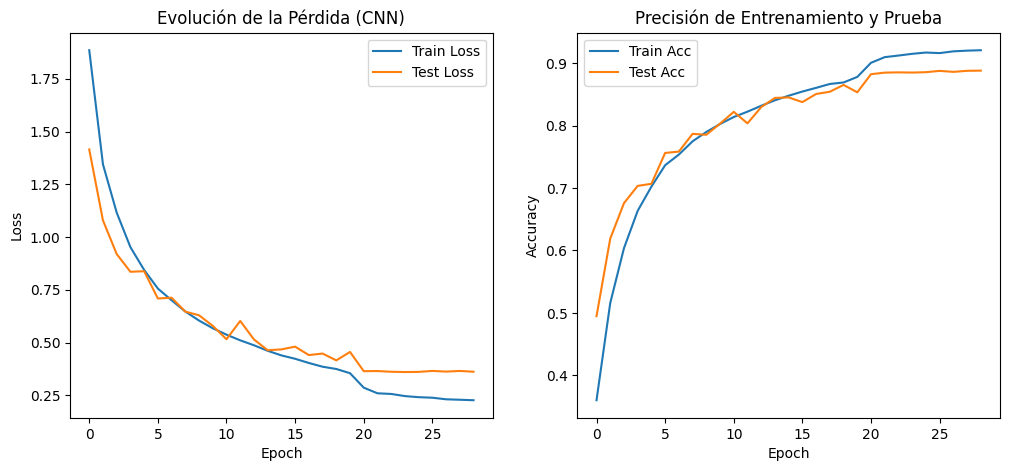

In [ ]:

# ==============================
# CONFIGURACION ENTRENAMIENTO
# ==============================
EPOCHS_CNN = 90
LEARNING_RATE_CNN = 0.001
EARLY_STOP_PATIENCE = 5
EARLY_STOP_DELTA = 1e-4

criterion_cnn = nn.CrossEntropyLoss()
model_cnn = ModeloCNN_MaxPool_pytorch(dropout_prob=0.3).to(device)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE_CNN)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_cnn, step_size=20, gamma=0.1)
scaler = torch.cuda.amp.GradScaler()

# Logs
perdidas_entrenamiento_cnn = []
perdidas_prueba_cnn = []
precision_entrenamiento_cnn = []
precision_prueba_cnn = []

# Early stopping
mejor_perdida_cnn = float('inf')
epocas_sin_mejora_cnn = 0

start_time_cnn_pt = time.time()

# ==============================
# BUCLE PRINCIPAL DE ENTRENAMIENTO
# ==============================
for epoch in range(EPOCHS_CNN):
    model_cnn.train()
    acumulado_perdida, correctos, total = 0.0, 0, 0

    for imagenes, etiquetas in train_loader:
        imagenes = imagenes.to(device, non_blocking=True)
        etiquetas = etiquetas.to(device, non_blocking=True)

        optimizer_cnn.zero_grad()

        with torch.cuda.amp.autocast():
            salidas = model_cnn(imagenes)
            perdida = criterion_cnn(salidas, etiquetas)

        scaler.scale(perdida).backward()
        scaler.step(optimizer_cnn)
        scaler.update()

        acumulado_perdida += perdida.item() * imagenes.size(0)
        _, prediccion = salidas.max(1)
        total += etiquetas.size(0)
        correctos += prediccion.eq(etiquetas).sum().item()

    perdida_train = acumulado_perdida / total
    precision_train = correctos / total

    perdidas_entrenamiento_cnn.append(perdida_train)
    precision_entrenamiento_cnn.append(precision_train)

    # ==============================
    # Evaluación en test
    # ==============================
    model_cnn.eval()
    acumulado_perdida, correctos, total = 0.0, 0, 0

    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes = imagenes.to(device, non_blocking=True)
            etiquetas = etiquetas.to(device, non_blocking=True)

            salidas = model_cnn(imagenes)
            perdida = criterion_cnn(salidas, etiquetas)

            acumulado_perdida += perdida.item() * imagenes.size(0)
            _, prediccion = salidas.max(1)
            total += etiquetas.size(0)
            correctos += prediccion.eq(etiquetas).sum().item()

    perdida_test = acumulado_perdida / total
    precision_test = correctos / total

    perdidas_prueba_cnn.append(perdida_test)
    precision_prueba_cnn.append(precision_test)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS_CNN}]  "
              f"Train Loss: {perdida_train:.4f}, Train Acc: {precision_train:.4f}  "
              f"Test Loss: {perdida_test:.4f}, Test Acc: {precision_test:.4f}")

    # Early stopping
    if perdida_test + EARLY_STOP_DELTA < mejor_perdida_cnn:
        mejor_perdida_cnn = perdida_test
        epocas_sin_mejora_cnn = 0
        torch.save(model_cnn.state_dict(), "best_model_cnn.pt")
    else:
        epocas_sin_mejora_cnn += 1
        if epocas_sin_mejora_cnn >= EARLY_STOP_PATIENCE:
            print(f"Early stopping: no mejora en {EARLY_STOP_PATIENCE} épocas.")
            break
    scheduler.step()

# ==============================
# Resultados finales
# ==============================
training_time_cnn_pt = time.time() - start_time_cnn_pt
print(f"\nTiempo total de entrenamiento CNN PyTorch: {training_time_cnn_pt:.2f} segundos")
print(f"Mejor precisión de prueba: {max(precision_prueba_cnn):.4f}")

# ==============================
# Gráficas
# ==============================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(perdidas_entrenamiento_cnn, label="Train Loss")
plt.plot(perdidas_prueba_cnn, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida (CNN)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(precision_entrenamiento_cnn, label="Train Acc")
plt.plot(precision_prueba_cnn, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Precisión de Entrenamiento y Prueba")
plt.legend()

plt.show()


#### MODELO CNN AVGPOOLING

In [ ]:
class ModeloCNN_avg_pytorch(nn.Module):
    def __init__(self, dropout_prob=0.2):
        super().__init__()

        # ---------------------------------------
        # Bloque conv inicial
        # ---------------------------------------
        self.conv_in = nn.Conv2d(3, 32, kernel_size=3, padding=1)
        self.bn_in = nn.BatchNorm2d(32)

        # ---------------------------------------
        # Bloque 1 (32 canales)
        # ---------------------------------------
        self.b1_conv1 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.b1_bn1  = nn.BatchNorm2d(32)
        self.b1_conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)
        self.b1_bn2  = nn.BatchNorm2d(32)

        # ---------------------------------------
        # Bloque 2 (32 → 64 canales)
        # ---------------------------------------
        self.b2_down = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)
        self.b2_bn_down = nn.BatchNorm2d(64)

        self.b2_conv1 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.b2_bn1  = nn.BatchNorm2d(64)
        self.b2_conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.b2_bn2  = nn.BatchNorm2d(64)

        # ---------------------------------------
        # Bloque 3 (64 → 128 canales)
        # ---------------------------------------
        self.b3_down = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1)
        self.b3_bn_down = nn.BatchNorm2d(128)

        self.b3_conv1 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.b3_bn1  = nn.BatchNorm2d(128)
        self.b3_conv2 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.b3_bn2  = nn.BatchNorm2d(128)

        # ---------------------------------------
        # Clasificador final
        # ---------------------------------------
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(dropout_prob)
        self.fc_out = nn.Linear(128, 10)

        self.relu = nn.ReLU(inplace=True)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    # ---------------------------------------
    # Bloque residual genérico conv-conv
    # ---------------------------------------
    def residual_block(self, x, conv1, bn1, conv2, bn2):
        identidad = x
        out = self.relu(bn1(conv1(x)))
        out = bn2(conv2(out))
        out += identidad
        return self.relu(out)

    def forward(self, x):

        # ========== Bloque inicial ==========
        x = self.relu(self.bn_in(self.conv_in(x)))

        # ========== BLOQUE 1 ==========
        x = self.residual_block(x, self.b1_conv1, self.b1_bn1,
                                   self.b1_conv2, self.b1_bn2)

        # ========== BLOQUE 2 ==========
        x = self.relu(self.b2_bn_down(self.b2_down(x)))
        x = self.residual_block(x, self.b2_conv1, self.b2_bn1,
                                   self.b2_conv2, self.b2_bn2)

        # ========== BLOQUE 3 ==========
        x = self.relu(self.b3_bn_down(self.b3_down(x)))
        x = self.residual_block(x, self.b3_conv1, self.b3_bn1,
                                   self.b3_conv2, self.b3_bn2)

        # ========== Clasificador ==========
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.fc_out(x)


C:\Users\Vismark Choque\AppData\Local\Temp\ipykernel_12652\3286643457.py:14: FutureWarning:

`torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.

C:\Users\Vismark Choque\AppData\Local\Temp\ipykernel_12652\3286643457.py:41: FutureWarning:

`torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.



Epoch [1/90]  Train Loss: 1.5520, Train Acc: 0.4309  Test Loss: 1.4244, Test Acc: 0.5138
Epoch [10/90]  Train Loss: 0.4828, Train Acc: 0.8335  Test Loss: 0.5331, Test Acc: 0.8241
Epoch [20/90]  Train Loss: 0.3137, Train Acc: 0.8923  Test Loss: 0.5422, Test Acc: 0.8383
Early stopping: no mejora en 5 épocas.

Tiempo total de entrenamiento CNN PyTorch: 855.62 segundos
Mejor precisión de prueba: 0.8918


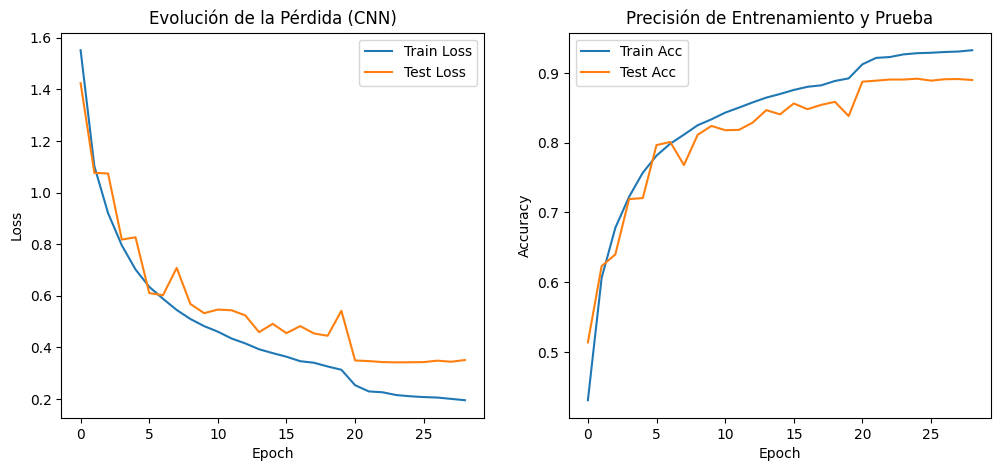

In [ ]:

# ==============================
# CONFIGURACIÓN ENTRENAMIENTO
# ==============================
EPOCHS_CNN = 90
LEARNING_RATE_CNN = 0.001
EARLY_STOP_PATIENCE = 5
EARLY_STOP_DELTA = 1e-4

criterion_cnn = nn.ModeloCNN_pytorch_avg()
model_cnn = ModeloCNN_avg_pytorch(dropout_prob=0.3).to(device)
optimizer_cnn = optim.Adam(model_cnn.parameters(), lr=LEARNING_RATE_CNN)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer_cnn, step_size=20, gamma=0.1)
# Mixed precision compatible con tu versión de PyTorch
scaler = torch.cuda.amp.GradScaler()

# Logs
perdidas_entrenamiento_cnn = []
perdidas_prueba_cnn = []
precision_entrenamiento_cnn = []
precision_prueba_cnn = []

# Early stopping
mejor_perdida_cnn = float('inf')
epocas_sin_mejora_cnn = 0

start_time_cnn_pt = time.time()

# ==============================
# BUCLE PRINCIPAL DE ENTRENAMIENTO
# ==============================
for epoch in range(EPOCHS_CNN):
    model_cnn.train()
    acumulado_perdida, correctos, total = 0.0, 0, 0

    for imagenes, etiquetas in train_loader:
        imagenes = imagenes.to(device, non_blocking=True)
        etiquetas = etiquetas.to(device, non_blocking=True)

        optimizer_cnn.zero_grad()

        with torch.cuda.amp.autocast():
            salidas = model_cnn(imagenes)
            perdida = criterion_cnn(salidas, etiquetas)

        scaler.scale(perdida).backward()
        scaler.step(optimizer_cnn)
        scaler.update()

        acumulado_perdida += perdida.item() * imagenes.size(0)
        _, prediccion = salidas.max(1)
        total += etiquetas.size(0)
        correctos += prediccion.eq(etiquetas).sum().item()

    perdida_train = acumulado_perdida / total
    precision_train = correctos / total

    perdidas_entrenamiento_cnn.append(perdida_train)
    precision_entrenamiento_cnn.append(precision_train)

    # ==============================
    # Evaluación en test
    # ==============================
    model_cnn.eval()
    acumulado_perdida, correctos, total = 0.0, 0, 0

    with torch.no_grad():
        for imagenes, etiquetas in test_loader:
            imagenes = imagenes.to(device, non_blocking=True)
            etiquetas = etiquetas.to(device, non_blocking=True)

            salidas = model_cnn(imagenes)
            perdida = criterion_cnn(salidas, etiquetas)

            acumulado_perdida += perdida.item() * imagenes.size(0)
            _, prediccion = salidas.max(1)
            total += etiquetas.size(0)
            correctos += prediccion.eq(etiquetas).sum().item()

    perdida_test = acumulado_perdida / total
    precision_test = correctos / total

    perdidas_prueba_cnn.append(perdida_test)
    precision_prueba_cnn.append(precision_test)

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS_CNN}]  "
              f"Train Loss: {perdida_train:.4f}, Train Acc: {precision_train:.4f}  "
              f"Test Loss: {perdida_test:.4f}, Test Acc: {precision_test:.4f}")

    # Early stopping
    if perdida_test + EARLY_STOP_DELTA < mejor_perdida_cnn:
        mejor_perdida_cnn = perdida_test
        epocas_sin_mejora_cnn = 0
        torch.save(model_cnn.state_dict(), "best_model_cnn.pt")
    else:
        epocas_sin_mejora_cnn += 1
        if epocas_sin_mejora_cnn >= EARLY_STOP_PATIENCE:
            print(f"Early stopping: no mejora en {EARLY_STOP_PATIENCE} épocas.")
            break
    scheduler.step()

# ==============================
# Resultados finales
# ==============================
training_time_cnn_pt = time.time() - start_time_cnn_pt
print(f"\nTiempo total de entrenamiento CNN PyTorch: {training_time_cnn_pt:.2f} segundos")
print(f"Mejor precisión de prueba: {max(precision_prueba_cnn):.4f}")

# ==============================
# Gráficas
# ==============================
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(perdidas_entrenamiento_cnn, label="Train Loss")
plt.plot(perdidas_prueba_cnn, label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolución de la Pérdida (CNN)")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(precision_entrenamiento_cnn, label="Train Acc")
plt.plot(precision_prueba_cnn, label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Precisión de Entrenamiento y Prueba")
plt.legend()

plt.show()


en los resultados obtenidos se puede visualizar que el modelo `ModeloCNN_avg_pytorch` tiene mejor precision de evalucion, las graficas nos muestran que este esta sobreajustando es decir la diferencia de perdida de entrenamiento y prueba se va alajando mas y mas en cambio con el modelo de `ModeloCNN_MaxPool_pytorch` este generaliza mejor existe diferencia en las perdidas pero este es menor, esta es la razon por la que se escoje este modelo.

---

## **TENSORFLOW CNN**


#### **MODELO**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, Model, initializers
# ============================================================
# Bloque residual generico conv-conv
# ============================================================
def residual_block(x, filters):
    identidad = x

    out = layers.Conv2D(
        filters, kernel_size=3, padding="same",
        kernel_initializer=initializers.HeNormal()
    )(x)
    out = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(out)
    out = layers.ReLU()(out)

    out = layers.Conv2D(
        filters, kernel_size=3, padding="same",
        kernel_initializer=initializers.HeNormal()
    )(out)
    out = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(out)

    out = layers.Add()([out, identidad])
    out = layers.ReLU()(out)
    return out

# ============================================================
# MODELO PRINCIPAL
# ============================================================
def ModeloCNN_MaxPool_tensorflow(dropout_prob=0.2):

    entrada = layers.Input(shape=(32, 32, 3))

    # ---------------------------------------
    # Bloque inicial
    # ---------------------------------------
    x = layers.Conv2D(
        32, kernel_size=3, padding="same",
        kernel_initializer=initializers.HeNormal()
    )(entrada)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)

    # ---------------------------------------
    # Bloque 1 (32 canales) con residual
    # ---------------------------------------
    x = residual_block(x, 32)

    # ---------------------------------------
    # Bloque 2 (32 -> 64 canales) downsample + residual
    # ---------------------------------------
    x = layers.Conv2D(
        64, kernel_size=3, strides=2, padding="same",
        kernel_initializer=initializers.HeNormal()
    )(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 64)

    # ---------------------------------------
    # Bloque 3 (64 -> 128 canales) downsample + residual
    # ---------------------------------------
    x = layers.Conv2D(
        128, kernel_size=3, strides=2, padding="same",
        kernel_initializer=initializers.HeNormal()
    )(x)
    x = layers.BatchNormalization(momentum=0.1, epsilon=1e-5)(x)
    x = layers.ReLU()(x)

    x = residual_block(x, 128)

    # ---------------------------------------
    # MaxPooling unico
    # ---------------------------------------
    x = layers.MaxPooling2D(pool_size=2, strides=2)(x)

    # ---------------------------------------
    # Flatten + Dropout + Clasificador
    # ---------------------------------------
    x = layers.Flatten()(x)
    x = layers.Dropout(dropout_prob)(x)
    salida = layers.Dense(
        10,
        kernel_initializer=initializers.HeNormal()
    )(x)

    return Model(inputs=entrada, outputs=salida)

#### **ENTRENAMIENTO**

Epoch 1/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 40s 55ms/step - accuracy: 0.2964 - loss: 2.3040 - val_accuracy: 0.5189 - val_loss: 1.3542 - learning_rate: 0.0010
Epoch 2/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.4876 - loss: 1.4222 - val_accuracy: 0.6108 - val_loss: 1.1111 - learning_rate: 0.0010
Epoch 3/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.5964 - loss: 1.1342 - val_accuracy: 0.6875 - val_loss: 0.8986 - learning_rate: 0.0010
Epoch 4/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.6690 - loss: 0.9450 - val_accuracy: 0.7142 - val_loss: 0.8119 - learning_rate: 0.0010
Epoch 5/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 8s 18ms/step - accuracy: 0.7098 - loss: 0.8289 - val_accuracy: 0.7596 - val_loss: 0.6888 - learning_rate: 0.0010
Epoch 6/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 10s 16ms/step - accuracy: 0.7415 - loss: 0.7344 - val_accuracy: 0.7572 - val_loss: 0.6904 - learning_rate: 0.0010
Epoch 7/90
391/391 ━━━━━━━━━━━━━━━━━━━━ 9s 19ms/step - accuracy: 0.7627 - loss: 

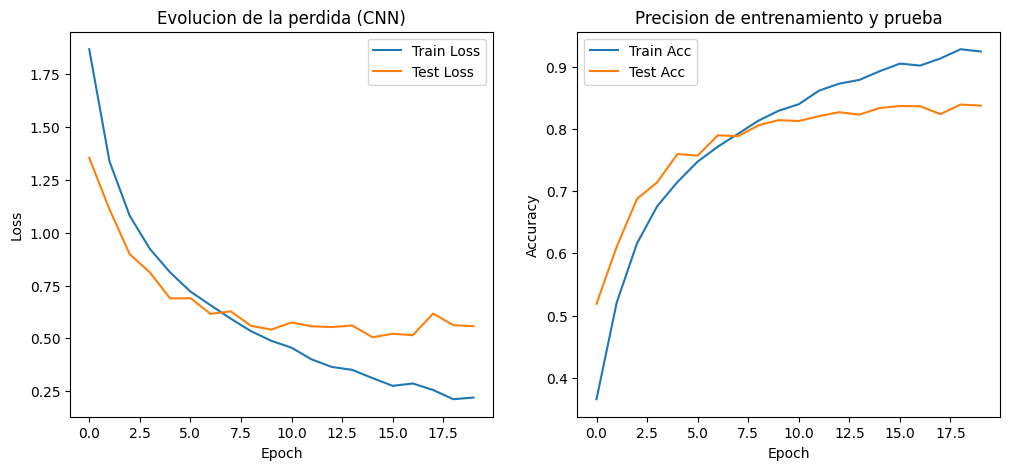

In [ ]:

# ==============================
# Configuracion entrenamiento
# ==============================
EPOCHS_CNN = 90
LEARNING_RATE_CNN = 0.001
EARLY_STOP_PATIENCE = 5
EARLY_STOP_DELTA = 1e-4

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_CNN)

def step_lr(epoch, lr):
    if epoch > 0 and epoch % 20 == 0:
        return lr * 0.1
    return lr

scheduler = tf.keras.callbacks.LearningRateScheduler(step_lr)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=EARLY_STOP_PATIENCE,
    min_delta=EARLY_STOP_DELTA,
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    "best_model_cnn_tf.weights.h5",
    monitor="val_loss",
    save_best_only=True,
    save_weights_only=True
)


# ==============================
# 7. Construir modelo CNN
# ==============================
model_tf = ModeloCNN_MaxPool_tensorflow(dropout_prob=0.3)

model_tf.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

# Mixed precision opcional
tf.keras.mixed_precision.set_global_policy("mixed_float16")

# ==============================
# 8. Entrenamiento
# ==============================
start_time = time.time()

hist = model_tf.fit(
    train_dataset,
    epochs=EPOCHS_CNN,
    validation_data=test_dataset,
    callbacks=[scheduler, early_stop, checkpoint],
    verbose=1
)

training_time_tf = time.time() - start_time
print(f"\nTiempo total de entrenamiento: {training_time_tf:.2f} segundos")
print(f"Mejor precision de prueba: {max(hist.history['val_accuracy']):.4f}")

# ==============================
# 9. Graficas
# ==============================
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(hist.history["loss"], label="Train Loss")
plt.plot(hist.history["val_loss"], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Evolucion de la perdida (CNN)")
plt.legend()

plt.subplot(1,2,2)
plt.plot(hist.history["accuracy"], label="Train Acc")
plt.plot(hist.history["val_accuracy"], label="Test Acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Precision de entrenamiento y prueba")
plt.legend()

plt.show()


## **5) ANALISIS Y RESULTADO CNN**

## **Analisis (CNN)**
En esta seccion se hace un analisis comparativo de modelos de reds neuronales convolucionales  (CNN) entrenados con el dataset CIFAR-10 utilizando los frameworks PyTorch y TensorFlow ambos utilizando la GPU para el trabajo en paralelo y mejorar la velocidad de entrenamiento


### Arquitectura del Modelo

Cabe mencionar que ambas arquitecturas realizadas en pytorch y tensorflow fueron realizadas lo mas equivalentes posibles.


- Tipo: Residual CNN con MaxPooling
- Estructura:
  - Bloques Convolucionales: 3 bloques principales con profundidad de canales creciente (32 -> 64 -> 128)
  - Bloques Residuales: Conv generica -> BN -> ReLU -> Conv -> BN -> Add -> ReLU
  - Pooling: MaxPooling (2x2)
  - Clasificador: Flatten -> Dropout (0.2) -> Dense/Linear (10 clases)
- Caracteristicas Clave:
  - Batch Normalization para estabilidad
  - Inicializacion He/Kaiming

### Comparacion de Rendimiento

| Metric | PyTorch CNN | TensorFlow CNN | Diferencia |
|--------|-------------|----------------|------------|
| Mejor Accuracy Test | 89.18% | 83.93% | PyTorch +5.25% |
| Tiempo de Entrenamiento | 794.82 sec | 204.19 sec | TF ~3.9x mas rapido |

### Observaciones
- Accuracy: PyTorch nuevamente supera a TensorFlow, alcanzando casi 89.2%
- Velocidad: TensorFlow mantiene ventaja, entrenando 4 veces mas rapido que PyTorch
- Seleccion de Modelo CNN CON PYTORCH: Variante MaxPooling generaliza mejor que AvgPooling, aunque AvgPooling tenia precision ligeramente mayor (sugiere que probablemente tenga un poco de overfitting)


---

---

# **CONCLUSIONES GENERALES**

- **Rendimiento en Accuracy**: Pytorch logra mayor precision tanto en DNN como en CNN destacando especialmente en la generalizacion del modelo  
  
- **Velocidad de Entrenamiento**: Tensorflow es significativamente mas rapido entrenando DNN y CNN varias veces mas rapido que Pytorch esto podria deberse optimizaciones de aprovechamiento de la GPU u otras

- **Exploracion de Modelos**: La velocidad de Tensorflow permite entrenar y evaluar rapidamente multiples modelos incluyendo arquitecturas mas profundas o modernas lo que facilita experimentacion y ajuste de hiperparametros  
- **Equilibrio entre velocidad y precision**
Los resultados obtenidos embase a las graficas y demas no dice:  
  - Si la prioridad es la maxima precision y generalizacion Pytorch es preferible  
  - Si la prioridad es la velocidad y la capacidad de probar muchas variantes de modelos Tensorflow ofrece una ventaja clara  
- **Eficiencia de Hardware**: La gran diferencia de tiempos en DNN Pytorch ~3500s vs Tensorflow ~360s indica que Pytorch puede estar limitado por la carga de datos o la utilizacion de GPU mientras que Tensorflow pareciera que optimiza mejor estos recursos  
